In [7]:
import numpy as np 
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

## Utilitários do Código

In [8]:
class LinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        X_pinv = np.linalg.pinv(X)
        self.w = X_pinv @ y
    
    def predict(self, X):
        return X @ self.w

In [9]:
def gaussian_rbf(X, centers, sigma):
    distis = torch.cdist(X, centers)
    return torch.exp( -(distis ** 2) / (2 * sigma**2) )

## Criação do Dataset

In [10]:
np.random.seed(42)
qtd_amostras = 150
X = np.linspace(-3, 3, qtd_amostras).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=qtd_amostras)

X_tensor = torch.tensor(X, dtype=torch.float32)

## Regressão Linear com RBF

In [11]:
n_centros_fixo = 10
centros_fixo = torch.linspace(-3, 3, steps=n_centros_fixo).view(-1, 1)
sigma = 0.5

X_expanded_torch = gaussian_rbf(X_tensor, centros_fixo, sigma)
X_expanded = X_expanded_torch.detach().numpy()

modelo_rbf = LinearRegression()
modelo_rbf.fit(X_expanded, y)
y_pred_rbf = modelo_rbf.predict(X_expanded)


## Modelo Híbrido (RBF com Centros de Subconjunto + Features Polinomiais)

In [12]:
n_centros_subset = 10
indices_subset = np.random.choice(qtd_amostras, n_centros_subset, replace=False)
centros_subset = torch.tensor(X[indices_subset], dtype=torch.float32)
sigma_subset = 0.5

X_rbf_subset_torch = gaussian_rbf(X_tensor, centros_subset, sigma_subset)

X_poly_torch = torch.hstack([X_tensor, X_tensor**2])

X_combined_torch = torch.hstack([X_rbf_subset_torch, X_poly_torch])
X_combined = X_combined_torch.detach().numpy()

modelo_hibrido = LinearRegression()
modelo_hibrido.fit(X_combined, y)
y_pred_hibrido = modelo_hibrido.predict(X_combined)

## Resultados

In [13]:
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
X_plot_tensor = torch.tensor(X_plot, dtype=torch.float32)

X_plot_expanded_torch = gaussian_rbf(X_plot_tensor, centros_fixo, sigma)
X_plot_expanded = X_plot_expanded_torch.detach().numpy()
y_plot_rbf = modelo_rbf.predict(X_plot_expanded)

X_plot_rbf_subset_torch = gaussian_rbf(X_plot_tensor, centros_subset, sigma_subset)
X_plot_poly_torch = torch.hstack([X_plot_tensor, X_plot_tensor**2])
X_plot_combined_torch = torch.hstack([X_plot_rbf_subset_torch, X_plot_poly_torch])
X_plot_combined = X_plot_combined_torch.detach().numpy()
y_plot_hibrido = modelo_hibrido.predict(X_plot_combined)

In [14]:
mse_rbf = np.mean((y - y_pred_rbf) ** 2)
mse_hibrido = np.mean((y - y_pred_hibrido) ** 2)

## Gráfico dos resultados

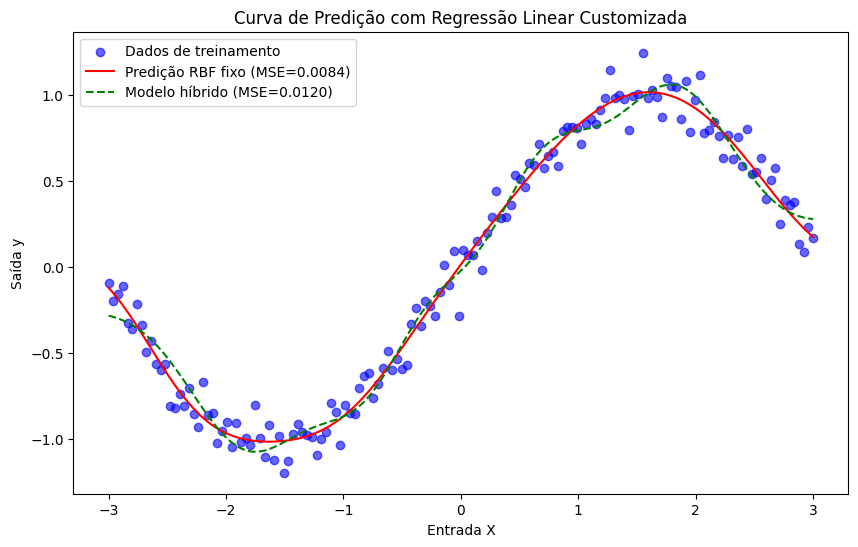

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados de treinamento', color='blue', alpha=0.6)
plt.plot(X_plot, y_plot_rbf, color='red', label=f'Predição RBF fixo (MSE={mse_rbf:.4f})')
plt.plot(X_plot, y_plot_hibrido, color='green', linestyle='--', label=f'Modelo híbrido (MSE={mse_hibrido:.4f})')
plt.title("Curva de Predição com Regressão Linear Customizada")
plt.xlabel("Entrada X")
plt.ylabel("Saída y")
plt.legend()
plt.show()